In [1]:
import pickle
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import umap
from dscribe.descriptors import SOAP

from gnome_dreams_oer_screening import Explog

# Shared colours/colormaps -- single source of truth in plot_style.py so this
# notebook and aq_gnome_fingerprints.ipynb/oer_results.ipynb stay visually
# consistent instead of each hand-picking their own.
from plot_style import GRAY, DEVIATION_CMAP, OVERPOTENTIAL_CMAP

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

c:\Users\matnis\OneDrive - Danmarks Tekniske Universitet\Skrivebord\Projects\material_agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Frozen EXPLOG snapshot sitting next to this notebook -- same file and
# loading pattern as oer_results.ipynb / aq_gnome_fingerprints.ipynb.
# Read-only: never touches the live workflow.
EXPLOG_PKL = Path("explog.pkl")

with open(EXPLOG_PKL, "rb") as f:
    payload = pickle.load(f)  # {"candidates_df", "processes_df"}

EXPLOG = Explog()
EXPLOG.init(Path(tempfile.mkdtemp(prefix="explog_probe_")), mode="test")
EXPLOG.relational_frame.candidates.df = payload["candidates_df"]
EXPLOG.relational_frame.processes.df = payload["processes_df"]
EXPLOG.job_handler._recompute_candidate_progress()

candidates = EXPLOG.relational_frame.candidates.df
print(f"{len(candidates)} EXPLOG candidates loaded")
candidates[["candidate_id", "Reduced Formula", "state", "decision"]].head()

139 EXPLOG candidates loaded


,candidate_id,Reduced Formula,state,decision
0,083fef92df,Fe(PtO3)2,active,Sufficient
1,6ace913656,TiSeO5,failed,Abandon
2,8ef62845e6,NiSe2O7,active,Sufficient
3,54d55ba8f4,CoBiTeO6,active,Sufficient
4,01ca2e7942,Zn3Ni(SeO4)4,active,Abandon


In [3]:
# Walk every inited surface study (study.get_surface_studies()) and pull
# out EVERY geometrically-identified adsorption site from
# surf_study.get_adsorption_sites_df() -- the full site table produced by
# determine_adsorption_sites(), independent of whether any DFT leg (or even
# an OER_adsorption_site_study) was ever started for a given site.
# G(O) / G(OH) / overpotential columns are NaN wherever that calc hasn't
# finished; NaNs are kept (not dropped) so the plot below can show every
# site as gray background and only color the subset with real data.
#
# All site types (on-top AND lattice O) use the SAME recipe: the surface's
# own base_surface_relaxed, centered on that site's atom_index. For
# "lattice O" sites the site atom already *is* the lattice oxygen -- that's
# what makes it a "lattice O" site -- so there's no separate placeholder
# position to special-case; the uniform recipe already centers on the O
# atom for these sites too.
METRIC_COLS = [
    "G(O)",
    "G(OH)",
    "ideal overpotential",
    "overpotential from OH-OOH scaling relation",
]

site_rows = []
surface_atoms_cache = {}  # (candidate_id, term_idx) -> Atoms, shared across all sites on that surface

for _, cand in candidates.iterrows():
    study = cand["study_obj"]
    if study is None:
        continue
    for term_idx, surf_study in study.get_surface_studies().items():
        df = surf_study.get_adsorption_sites_df()
        if df is None:
            continue  # adsorption sites not determined yet for this surface

        atoms = surf_study.base_surface_relaxed.copy()
        surface_atoms_cache[(cand["candidate_id"], term_idx)] = atoms

        for _, row in df.iterrows():
            row_data = {
                "candidate_id": cand["candidate_id"],
                "Reduced Formula": cand["Reduced Formula"],
                "termination": term_idx,
                "site_index": int(row["Site index"]),
                "site_type": row["site type"],
                "atom_index": int(row["atom_index"]),
            }
            for col in METRIC_COLS:
                row_data[col] = row.get(col, np.nan)
            site_rows.append(row_data)

sites_struct_df = pd.DataFrame(site_rows)
print(f"{len(sites_struct_df)} geometrically-identified adsorption sites "
      f"collected across {sites_struct_df['candidate_id'].nunique()} candidates")
print("by site type:", sites_struct_df["site_type"].value_counts().to_dict())
for col in METRIC_COLS:
    print(f"  sites with {col}: {int(sites_struct_df[col].notna().sum())}")
sites_struct_df.drop(columns=METRIC_COLS).head(10)

714 geometrically-identified adsorption sites collected across 118 candidates
by site type: {'on-top': 522, 'lattice O': 192}
  sites with G(O): 242
  sites with G(OH): 98
  sites with ideal overpotential: 98
  sites with overpotential from OH-OOH scaling relation: 98


,candidate_id,Reduced Formula,termination,site_index,site_type,atom_index
0,083fef92df,Fe(PtO3)2,13,0,on-top,2
1,083fef92df,Fe(PtO3)2,13,1,on-top,7
2,083fef92df,Fe(PtO3)2,12,0,on-top,2
3,083fef92df,Fe(PtO3)2,12,1,on-top,10
4,083fef92df,Fe(PtO3)2,1,0,on-top,5
5,083fef92df,Fe(PtO3)2,1,1,on-top,19
6,083fef92df,Fe(PtO3)2,1,3,on-top,21
7,8ef62845e6,NiSe2O7,7,0,on-top,6
8,8ef62845e6,NiSe2O7,7,1,on-top,19
9,8ef62845e6,NiSe2O7,7,2,on-top,20


In [4]:
# One shared SOAP descriptor for every structure -- `species` must be fixed
# up front (not inferred per-structure) so every site's vector comes out the
# same length. All sites on the same surface share the same underlying
# relaxed-surface Atoms object, so SOAP is computed once per surface for all
# of that surface's site centers together (batched via `centers=[...]`),
# rather than once per site -- avoids rebuilding the same neighbor list
# 3-4x over for surfaces with multiple sites.
all_species = sorted({el for atoms in surface_atoms_cache.values() for el in atoms.get_chemical_symbols()})
print(f"{len(all_species)} distinct elements across all collected structures: {all_species}")

R_CUT = 6.0  # Angstrom cutoff around the site atom -- a few coordination shells
N_MAX = 6
L_MAX = 4

# Default (uncompressed) SOAP scales ~quadratically with len(all_species) --
# with 41 elements pooled across every structure that was 151,905 dims/site,
# 827 MiB just for X_soap and an easy MemoryError on vstack. "mu1nu1" scales
# linearly with element count instead (~40x smaller here) while still keeping
# species-resolved information, unlike "mu2" which drops species distinction
# entirely -- see https://doi.org/10.1038/s41524-022-00847-y.
soap = SOAP(r_cut=R_CUT, n_max=N_MAX, l_max=L_MAX, species=all_species, periodic=True,
            compression={"mode": "mu1nu1"})

soap_batches = []
row_order = []
for (cand_id, term_idx), group in sites_struct_df.groupby(["candidate_id", "termination"], sort=False):
    atoms = surface_atoms_cache[(cand_id, term_idx)]
    centers = group["atom_index"].tolist()
    soap_batches.append(np.atleast_2d(soap.create(atoms, centers=centers, n_jobs=1)))
    row_order.extend(group.index.tolist())

X_soap = np.vstack(soap_batches)
X_soap = X_soap[np.argsort(row_order)]  # groupby scrambles row order -- realign to sites_struct_df's order

print(f"encoded {X_soap.shape[0]} adsorption sites into {X_soap.shape[1]}-dim SOAP descriptors")

41 distinct elements across all collected structures: ['Ag', 'Al', 'Bi', 'Br', 'Ce', 'Co', 'Cr', 'Cu', 'Dy', 'Er', 'Eu', 'Fe', 'Ga', 'I', 'In', 'Ir', 'K', 'La', 'Mg', 'Mn', 'Mo', 'N', 'Nd', 'Ni', 'O', 'Pr', 'Pt', 'Re', 'Rh', 'Ru', 'Sb', 'Se', 'Sm', 'Sr', 'Tb', 'Te', 'Ti', 'V', 'W', 'Y', 'Zn']
encoded 714 adsorption sites into 7380-dim SOAP descriptors


In [5]:
# Fit all 9 (n_neighbors, min_dist) combos once, keeping each panel's own
# embedding -- lets the plot cell below redraw instantly without redoing any
# of these (slow) UMAP fits, so you can pick params before running the
# colored 3-panel plot further down. Same pattern as aq_gnome_fingerprints.ipynb.
from itertools import product
from tqdm import tqdm

grid_n_neighbors = [5, 15, 50]
grid_min_dist = [0.0, 0.25, 1.0]
grid_params = list(product(enumerate(grid_n_neighbors), enumerate(grid_min_dist)))

grid_results = []
for (i, nn), (j, md) in tqdm(grid_params, desc="UMAP grid"):
    nn = min(nn, len(X_soap) - 1)
    grid_embedding = umap.UMAP(n_neighbors=nn, min_dist=md, random_state=0, n_jobs=1).fit_transform(X_soap)
    grid_results.append({"i": i, "j": j, "n_neighbors": nn, "min_dist": md, "embedding": grid_embedding})

UMAP grid:   0%|          | 0/9 [00:00<?, ?it/s]c:\Users\matnis\OneDrive - Danmarks Tekniske Universitet\Skrivebord\Projects\material_agent\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
UMAP grid:  11%|█         | 1/9 [00:11<01:29, 11.15s/it]c:\Users\matnis\OneDrive - Danmarks Tekniske Universitet\Skrivebord\Projects\material_agent\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
UMAP grid:  22%|██▏       | 2/9 [00:12<00:37,  5.37s/it]c:\Users\matnis\OneDrive - Danmarks Tekniske Universitet\Skrivebord\Projects\material_agent\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
UMAP grid: 100%|██████████| 9/9 [00:25<00:

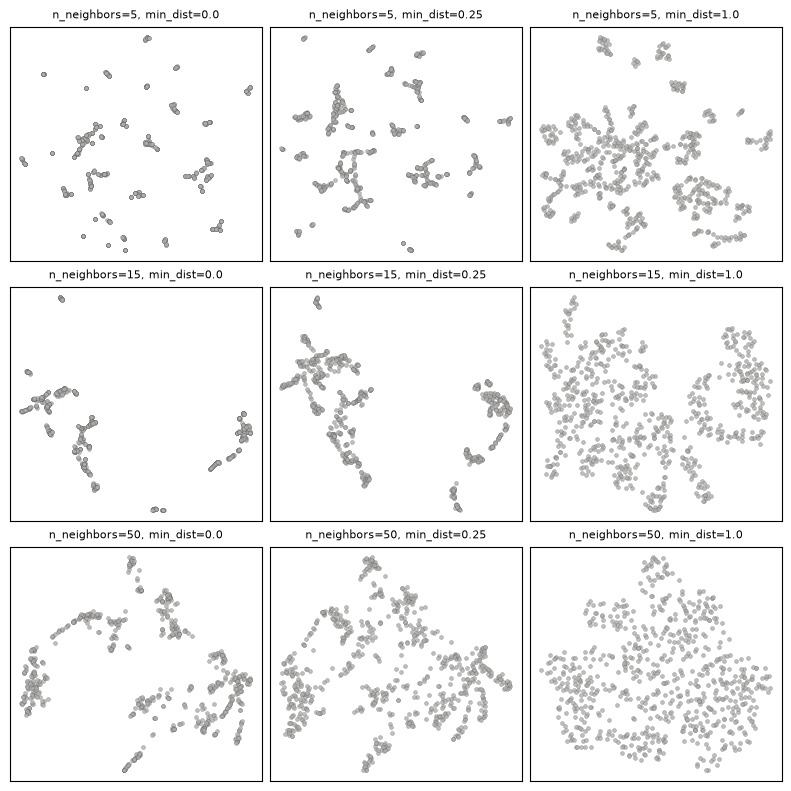

In [6]:
# Redraws the 9 panels from grid_results -- no UMAP calls, so cheap to rerun.
fig, axes = plt.subplots(len(grid_n_neighbors), len(grid_min_dist),
                          figsize=(2.6 * len(grid_min_dist), 2.6 * len(grid_n_neighbors)),
                          constrained_layout=True)

for g in grid_results:
    ax = axes[g["i"], g["j"]]
    ax.scatter(g["embedding"][:, 0], g["embedding"][:, 1], s=8, color=GRAY,
               edgecolor="0.3", linewidth=0.2, alpha=0.8)
    ax.set_title(f"n_neighbors={g['n_neighbors']}, min_dist={g['min_dist']}", fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

In [7]:
# Pick UMAP params from the grid above -- these drive the "final" 3-panel
# plot below.
CHOSEN_N_NEIGHBORS = 50
CHOSEN_MIN_DIST = 0.25

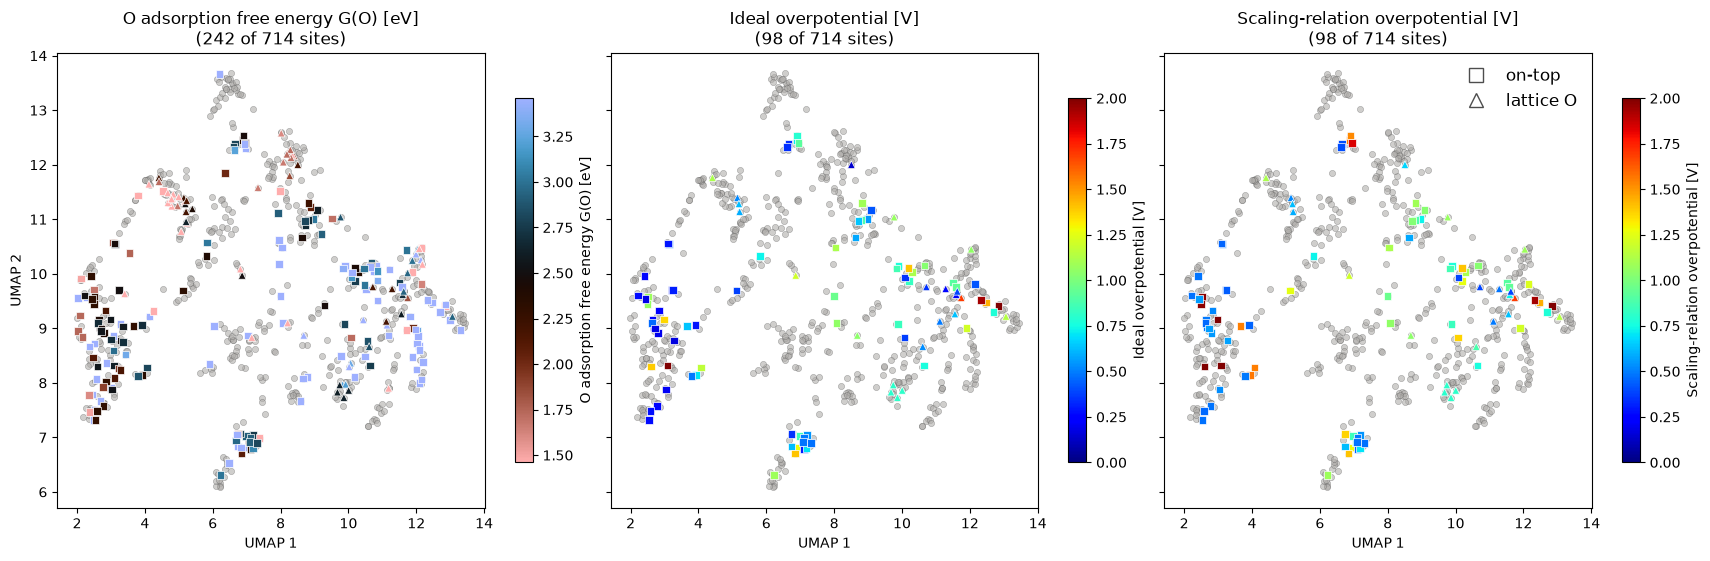

In [8]:
# Set to False to plot every site with one uniform marker (color still
# encodes the metric); set to True to also distinguish site_type by marker
# shape (on-top = circle, lattice O = triangle).
DISTINGUISH_SITE_TYPE_MARKER = True

SITE_TYPE_MARKERS = {"on-top": "s", "lattice O": "^"}
PANELS = [
    ("G(O)", "O adsorption free energy G(O) [eV]", "berlin_r", (2.46 - 1, 2.46 + 1)),
    ("ideal overpotential", "Ideal overpotential [V]", OVERPOTENTIAL_CMAP, (0.0, 2.0)),
    ("overpotential from OH-OOH scaling relation", "Scaling-relation overpotential [V]", OVERPOTENTIAL_CMAP, (0.0, 2.0)),
]

n_neighbors = min(CHOSEN_N_NEIGHBORS, len(X_soap) - 1)
reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=CHOSEN_MIN_DIST, random_state=0, n_jobs=1)
embedding = reducer.fit_transform(X_soap)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5), constrained_layout=True,
                          sharex=True, sharey=True)

for ax, (col, label, cmap, vlim) in zip(axes, PANELS):
    values = sites_struct_df[col].to_numpy(dtype=float)
    has_value = ~np.isnan(values)

    # Gray backdrop: every collected site, regardless of whether this metric is known.
    ax.scatter(embedding[:, 0], embedding[:, 1], s=20, color=GRAY,
               edgecolor="0.3", linewidth=0.3, alpha=0.6, zorder=4)

    vmin, vmax = vlim if vlim is not None else (np.nanmin(values), np.nanmax(values))
    sc = None
    if DISTINGUISH_SITE_TYPE_MARKER:
        for site_type, marker in SITE_TYPE_MARKERS.items():
            mask = has_value & (sites_struct_df["site_type"].to_numpy() == site_type)
            if not mask.any():
                continue
            sc = ax.scatter(embedding[mask, 0], embedding[mask, 1], c=values[mask],
                             cmap=cmap, vmin=vmin, vmax=vmax, marker=marker, s=30,
                             edgecolor="white", linewidth=0.5, zorder=6)
    else:
        sc = ax.scatter(embedding[has_value, 0], embedding[has_value, 1], c=values[has_value],
                         cmap=cmap, vmin=vmin, vmax=vmax, s=30,
                         edgecolor="white", linewidth=0.5, zorder=6)

    ax.set_xlabel("UMAP 1")
    ax.set_title(f"{label}\n({int(has_value.sum())} of {len(values)} sites)")
    if sc is not None:
        fig.colorbar(sc, ax=ax, label=label, shrink=0.8)

axes[0].set_ylabel("UMAP 2")

if DISTINGUISH_SITE_TYPE_MARKER:
    legend_handles = [
        Line2D([0], [0], marker=m, color="0.3", linestyle="",
               markerfacecolor="white", markeredgecolor="0.3", markersize=10, label=st)
        for st, m in SITE_TYPE_MARKERS.items()
    ]
    axes[-1].legend(handles=legend_handles, frameon=False, fontsize=12, loc="best")

plt.show()